In [33]:
import wrds
import datetime
import numpy as np
import pandas as pd
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:



# Matteo's original actions and stakeholders
def dict_2d_actions_stakeholders_original_matteo(signal_0_name="advocacy", signal_1_name="preparation", signal_2_name="transformation"):
    
    return{
        # 'TYPE: association': 0, 
        # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
        'TYPE: donation & funding': 0, 
        'TYPE: volunteerism': 0, 
        'TYPE_SREC: communication - local communities and society': 0, 
        'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
        'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
        'TYPE_SREC: organizational structuring - local communities and society': 0, 

        'TYPE: adoption of standards and rules': 1, 
        'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
        'TYPE_SREC: communication - employees': 1, 
        'TYPE_SREC: training - employees': 1, 
        'TYPE_SREC: incentives - employees': 1, 
        'TYPE_SREC: organizational structuring - employees': 1, 

        'TYPE: asset modification': 2,
        'TYPE: modification of procedures': 2, 
        'TYPE: new products': 2, 
        'TYPE: r&d investments': 2, 
        'TYPE_SREC: communication - customers': 2, 
        'TYPE_SREC: communication - shareholders': 2, 
        'TYPE_SREC: communication - suppliers': 2, 
        'TYPE_SREC: training - customers': 2, 
        'TYPE_SREC: training - shareholders': 2, 
        'TYPE_SREC: training - suppliers': 2, 
        'TYPE_SREC: incentives - customers': 2, 
        'TYPE_SREC: incentives - shareholders': 2, 
        'TYPE_SREC: incentives - suppliers': 2, 
        'TYPE_SREC: organizational structuring - customers': 2, 
        'TYPE_SREC: organizational structuring - shareholders': 2, 
        'TYPE_SREC: organizational structuring - suppliers': 2, 
    }, signal_0_name, signal_1_name, signal_2_name

categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

### 4. EDA

In [35]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"

lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')



start_year = 2013
end_year = 2024
lc = lc[lc['rfyear'] >= start_year]
lc = lc[lc['rfyear'] <= end_year]
lc = lc[lc['loc'] == 'JPN']


In [36]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [37]:
# multiple stats per year
lc.groupby("rfyear")["sum_activities"].agg(["count", "mean", "median", "sum"])

,count,mean,median,sum
rfyear,,,,
2013.0,310,43.067742,29.0,13351.0
2014.0,346,48.000000,32.0,16608.0
2015.0,365,45.671233,31.0,16670.0
2016.0,406,37.830049,25.0,15359.0
2017.0,429,36.121212,22.0,15496.0
2018.0,478,29.108787,18.0,13914.0
2019.0,509,28.858546,18.0,14689.0
2020.0,587,30.551959,18.0,17934.0
2021.0,702,29.729345,16.5,20870.0


In [38]:
lc.loc[lc['loc'] == 'JPN', 'gvkey'].unique().shape

(1236,)

In [39]:
# MANUAL INPUT

#change below to the above sdg - evn and non env>
plt_title_suffix = 'Innovation'
plt_max_to_min_title_suffix = 'Innovation to advocacy'

# FIND MIN AND MAX CATEGORY ID
min_category = min(categories_dict.values())
max_category = max(categories_dict.values())



##### REGION

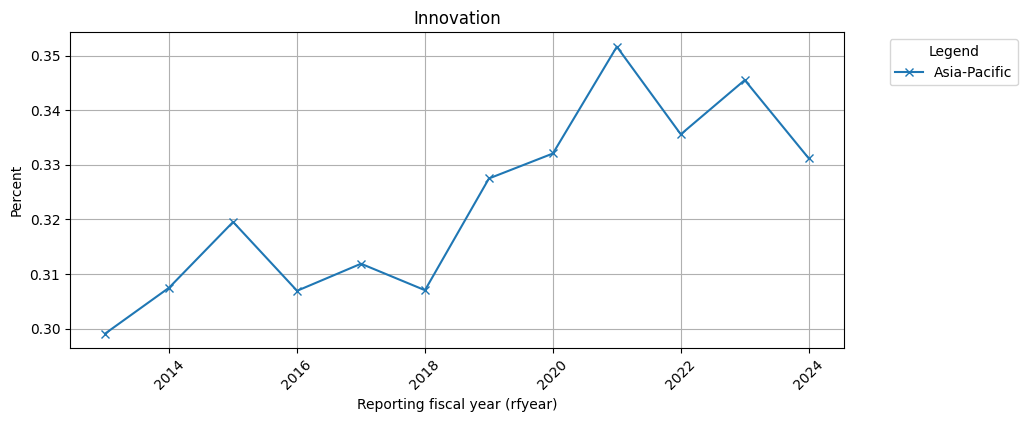

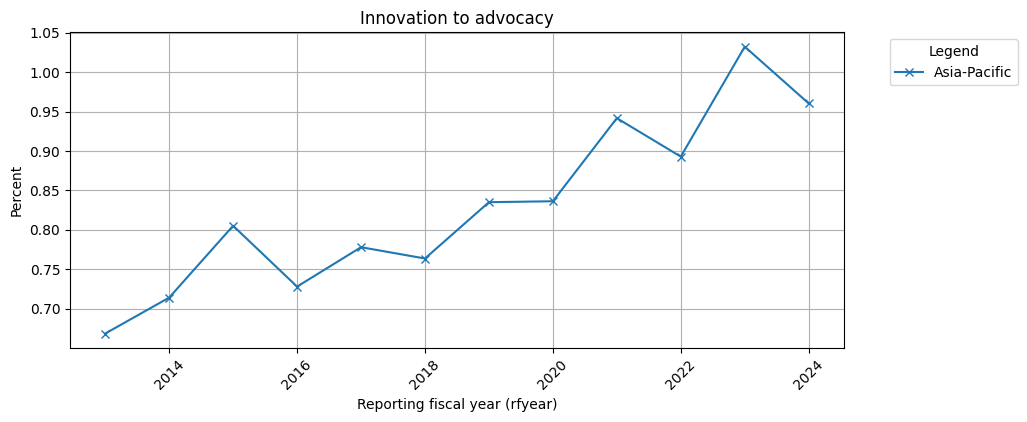

In [40]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_region_long['ratio'] = ratio_region_long[f'sum_with_{max_category}']/ratio_region_long[f'sum_activities']
ratio_region = pd.pivot(ratio_region_long, index='rfyear', columns='MacroRegion', values='ratio')

# Iterate over each column in the DataFrame to plot
for column in ratio_region.columns:
    plt.plot(ratio_region.index, ratio_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/headline_region_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_region_long['ratio_max_to_min'] = ratio_max_to_min_region_long[f'sum_with_{max_category}']/ratio_max_to_min_region_long[f'sum_with_{min_category}']
ratio_max_to_min_region = pd.pivot(ratio_max_to_min_region_long, index='rfyear', columns='MacroRegion', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for column in ratio_max_to_min_region.columns:
    plt.plot(ratio_max_to_min_region.index, ratio_max_to_min_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/core_region_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

##### GICS

In [42]:
def map_sectors(x):
    # Skip Industrials, Health Care, Utilities
    if x in ['Energy', 'Materials']:
        return 'Primary Industries'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer'

    # make Financial = Financials if you want to include finance sector
    elif x in ['Financials', 'Real Estate']:
        return 'Financial'
    elif x in ['Communication Services', 'Information Technology']:
        return 'ICT'
    return x

In [43]:
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

In [44]:
# Define a CVD-friendly colour map and line styles
colours = plt.cm.viridis(np.linspace(0, 1, len(lc['Industry'].unique())))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'x', '*']

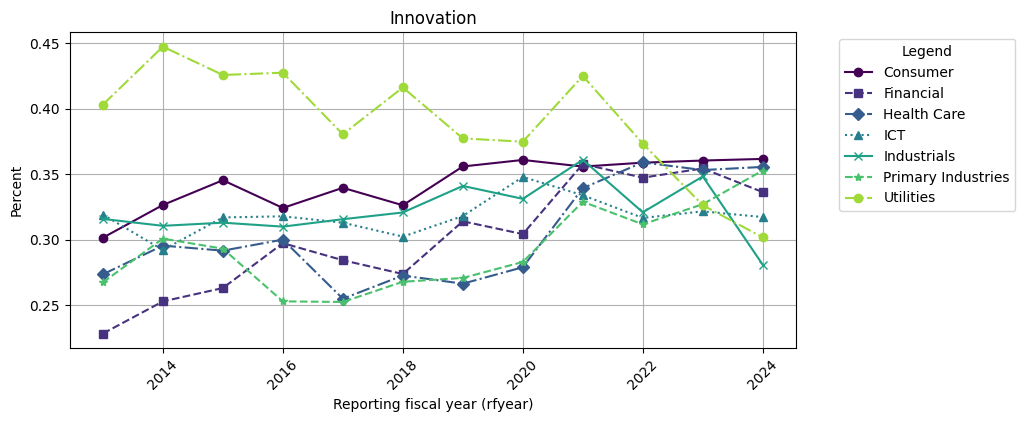

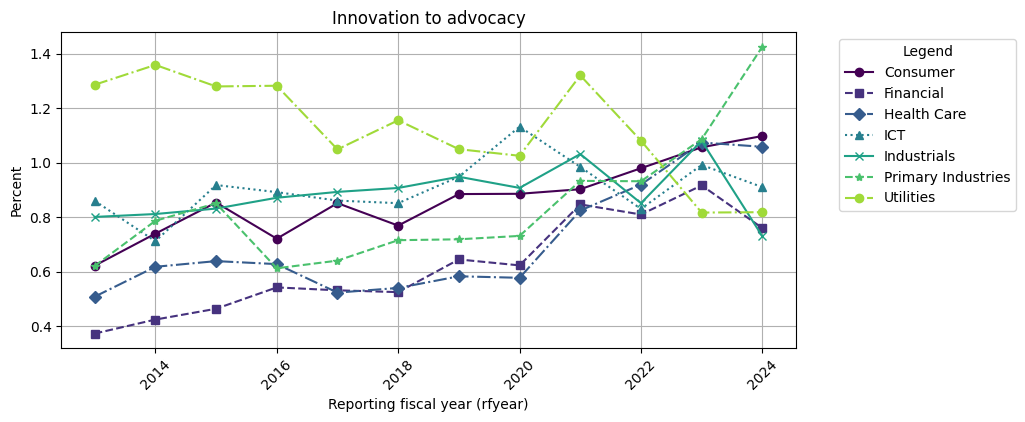

In [45]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_gics_long['ratio'] = ratio_gics_long[f'sum_with_{max_category}']/ratio_gics_long[f'sum_activities']
ratio_gics = pd.pivot(ratio_gics_long, index='rfyear', columns='Industry', values='ratio')

# Iterate over each column in the DataFrame to plot
# Plot each column in the DataFrame
for idx, (column, colour) in enumerate(zip(ratio_gics.columns, colours)):
    plt.plot(ratio_gics.index, ratio_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/headline_gics_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_gics_long['ratio_max_to_min'] = ratio_max_to_min_gics_long[f'sum_with_{max_category}']/ratio_max_to_min_gics_long[f'sum_with_{min_category}']
ratio_max_to_min_gics = pd.pivot(ratio_max_to_min_gics_long, index='rfyear', columns='Industry', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for idx, (column, colour) in enumerate(zip(ratio_max_to_min_gics.columns, colours)):
    plt.plot(ratio_max_to_min_gics.index, ratio_max_to_min_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
#plt.savefig(f'./img/core_gics_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()